**we dont care about the error for the points which are in epsilon insensitive tube**

kernels-jo transformation ham use karte h jaha pe data points ko ham clearly seperate karega,jo lower dimension hota h wo transformation ke bad higher dimension ho jata h

any point outside this tube is a vector and they are the ones supporting the strucgture or formation of the tube therefore it is called support vector regression


for the models that have implicit relation between the dependent variable y and features x ,we have to apply feature sccaling

**importing the libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**importing the dataset**

In [ ]:
dataset=pd.read_csv('Position_Salaries.csv')
x=dataset.iloc[:,1:-1].values
y=dataset.iloc[:,-1].values

In [ ]:
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [ ]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [ ]:
y=y.reshape(len(y),1)

In [ ]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


**feature scaling**

we apply this feature scaling on teh whole dataset as we have no x_train and x_test

we have to apply feature scaling for dependent variable y here ,because we dont want model to ignore the 'level' feature which takes much lower value than salary

we have to create 2 objects of standard scalar here as each object calculates mean and deviation of its associated feature or variable.

standardisation usually transforms your values between -3 and +3

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
x=sc_x.fit_transform(x)
y=sc_y.fit_transform(y)

In [ ]:
print(x)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [ ]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


**Training the SVR model on the whole dataset**

rbf=radial basis funtion

In [ ]:
from sklearn.svm import SVR
regressor=SVR(kernel='rbf')
regressor.fit(x,y)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

**Predicting a new result**

In [ ]:
sc_y.inverse_transform(regressor.predict(sc_x.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

**visualising Polynomial regression results**

here x,y are scaled values ,we can revedrse transform them to plot with original values(see the following cell)

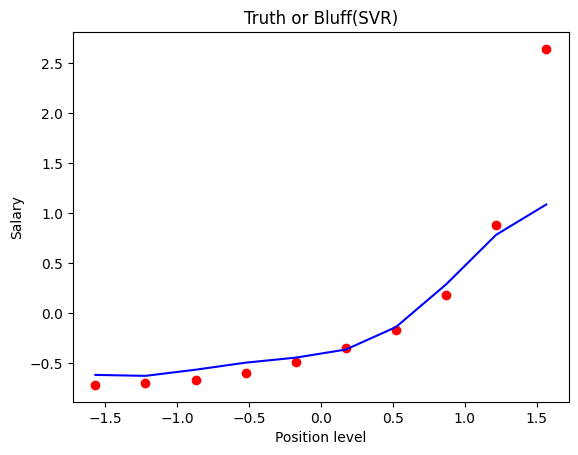

In [ ]:
plt.scatter(x,y,color='red')
plt.plot(x,regressor.predict(x),color='blue')
plt.title('Truth or Bluff(SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

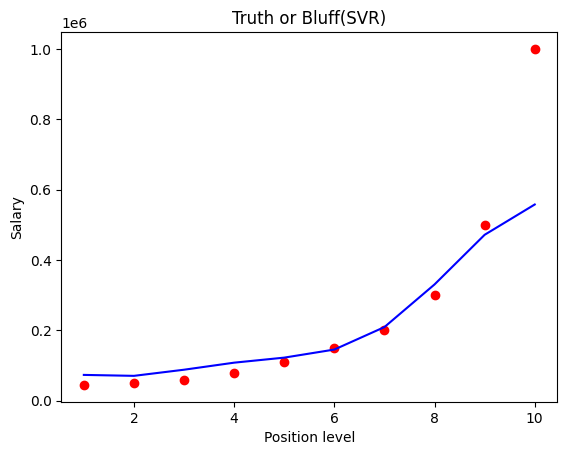

In [ ]:
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y),color='red')
plt.plot(sc_x.inverse_transform(x),sc_y.inverse_transform(regressor.predict(x).reshape(-1,1)),color='blue')
plt.title('Truth or Bluff(SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()